# Pre-processing Pipeline – Spatial & Radiometric Standardization

This notebook takes raw DICOM CT volumes and produces uniform **128 × 128 × 128** 
volumes at **1 mm isotropic** spacing with **bone windowing**, ready for downstream 
3D reconstruction and fracture segmentation.

## 1. Imports & Configuration

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
DATA_DIR_LEFT  = PROJECT_ROOT / "data" / "raw" / "fractured" / "PartLeft"
DATA_DIR_RIGHT = PROJECT_ROOT / "data" / "raw" / "fractured" / "PartRight"
OUTPUT_DIR     = PROJECT_ROOT / "data" / "processed" / "fractured"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Pipeline constants ─────────────────────────────────────────
TARGET_SPACING = (1.0, 1.0, 1.0)   # mm – isotropic
TARGET_SHAPE   = (128, 128, 128)   # voxels – final crop
BONE_WINDOW_CENTER = 400           # HU
BONE_WINDOW_WIDTH  = 1800          # HU  →  range [−500, 1300]
MIN_SLICES = 3                     # skip scout / localizer images

print("Configuration ready.")
print(f"  Target spacing : {TARGET_SPACING}")
print(f"  Target shape   : {TARGET_SHAPE}")
print(f"  Bone window    : center={BONE_WINDOW_CENTER}, width={BONE_WINDOW_WIDTH}")
print(f"  Output dir     : {OUTPUT_DIR}")

Configuration ready.
  Target spacing : (1.0, 1.0, 1.0)
  Target shape   : (128, 128, 128)
  Bone window    : center=400, width=1800
  Output dir     : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\fractured


## 2. Data Discovery & Filtering

In [3]:
def get_case_directories(base_dir, part_name):
    """Discover case directories under a given part directory."""
    cases = []
    base = Path(base_dir)
    if base.exists():
        for case_path in sorted(base.iterdir()):
            if case_path.is_dir():
                cases.append({
                    "case_id": case_path.name,
                    "part": part_name,
                    "case_path": str(case_path),
                })
    return cases


def extract_dicom_metadata(case_path):
    """Return (size, spacing) for a DICOM series, or (None, None) on failure."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(case_path)
    if not dicom_names:
        return None, None
    reader.SetFileNames(dicom_names)
    try:
        img = reader.Execute()
        return img.GetSize(), img.GetSpacing()
    except Exception as e:
        print(f"  ⚠ Error reading {case_path}: {e}")
        return None, None


# Discover all cases
all_cases = []
all_cases.extend(get_case_directories(DATA_DIR_LEFT,  "PartLeft"))
all_cases.extend(get_case_directories(DATA_DIR_RIGHT, "PartRight"))

df_cases = pd.DataFrame(all_cases)

# Extract metadata
print("Extracting metadata …")
sizes, spacings = [], []
for _, row in df_cases.iterrows():
    sz, sp = extract_dicom_metadata(row["case_path"])
    sizes.append(sz)
    spacings.append(sp)

df_cases["original_size"]    = sizes
df_cases["original_spacing"] = spacings

# Filter out degenerate cases (≤ MIN_SLICES)
df_cases["z_slices"] = df_cases["original_size"].apply(
    lambda s: s[2] if s is not None else 0
)
mask_valid = df_cases["z_slices"] >= MIN_SLICES
df_valid   = df_cases[mask_valid].reset_index(drop=True)
df_skipped = df_cases[~mask_valid]

print(f"\nTotal cases found : {len(df_cases)}")
print(f"Valid cases       : {len(df_valid)}")
print(f"Skipped cases     : {len(df_skipped)}")

if len(df_skipped) > 0:
    print("\nSkipped (too few slices):")
    display(df_skipped[["case_id", "part", "z_slices"]])

print("\nValid cases:")
display(df_valid[["case_id", "part", "original_size", "original_spacing"]])

Extracting metadata …

Total cases found : 16
Valid cases       : 14
Skipped cases     : 2

Skipped (too few slices):


,case_id,part,z_slices
3,Case4,PartLeft,1
4,Case10,PartRight,1



Valid cases:


,case_id,part,original_size,original_spacing
0,Case1,PartLeft,"(512, 512, 103)","(0.4296875, 0.4296875, 3.0)"
1,Case2,PartLeft,"(512, 512, 85)","(0.4296875, 0.4296875, 3.0)"
2,Case3,PartLeft,"(512, 512, 82)","(0.38671875, 0.38671875, 3.0)"
3,Case11,PartRight,"(512, 512, 340)","(0.3671875, 0.3671875, 0.6999999999999998)"
4,Case12,PartRight,"(512, 512, 397)","(0.447265625, 0.447265625, 0.7000000000000001)"
5,Case13,PartRight,"(512, 512, 361)","(0.466796875, 0.466796875, 0.7)"
6,Case14,PartRight,"(512, 512, 418)","(0.390625, 0.390625, 0.6999999999999996)"
7,Case15,PartRight,"(512, 512, 71)","(0.365234375, 0.365234375, 3.0)"
8,Case16,PartRight,"(512, 512, 337)","(0.427734375, 0.427734375, 0.6999999999999998)"
9,Case5,PartRight,"(512, 512, 72)","(0.3828125, 0.3828125, 3.0)"


## 3. DICOM Loading

In [4]:
def load_dicom_volume(case_path: str) -> sitk.Image:
    """Load a DICOM series as a 3-D SimpleITK image (HU values)."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(case_path)
    reader.SetFileNames(dicom_names)
    reader.MetaDataDictionaryArrayUpdateOn()
    reader.LoadPrivateTagsOn()
    image = reader.Execute()
    # SimpleITK automatically applies RescaleSlope / RescaleIntercept
    # so the pixel values are already in Hounsfield Units.
    return image


# Quick sanity check on the first valid case
sample_path = df_valid.iloc[0]["case_path"]
sample_img  = load_dicom_volume(sample_path)
print(f"Sample case : {df_valid.iloc[0]['case_id']}")
print(f"  Size      : {sample_img.GetSize()}")
print(f"  Spacing   : {tuple(round(s, 4) for s in sample_img.GetSpacing())}")
print(f"  Origin    : {tuple(round(o, 2) for o in sample_img.GetOrigin())}")
print(f"  Direction : {sample_img.GetDirection()}")

Sample case : Case1
  Size      : (512, 512, 103)
  Spacing   : (0.4297, 0.4297, 3.0)
  Origin    : (-134.79, -239.79, -58.1)
  Direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


## 4. Spatial Standardization

1. **Resample** to isotropic 1 mm × 1 mm × 1 mm using **linear interpolation**.  
2. **Center-crop or zero-pad** to a fixed 128 × 128 × 128 volume.

In [5]:
def resample_to_isotropic(
    image: sitk.Image,
    target_spacing: tuple = TARGET_SPACING,
    interpolator=sitk.sitkLinear,
    default_value: float = -1000.0,   # air in HU
) -> sitk.Image:
    """Resample an image to the target isotropic spacing."""
    original_spacing = image.GetSpacing()
    original_size    = image.GetSize()

    # Compute new grid size so that the physical extent is preserved
    new_size = [
        int(round(osz * osp / tsp))
        for osz, osp, tsp in zip(original_size, original_spacing, target_spacing)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(image.GetDirection())
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(default_value)
    resampler.SetInterpolator(interpolator)

    return resampler.Execute(image)


def center_crop_or_pad(
    image: sitk.Image,
    target_shape: tuple = TARGET_SHAPE,
    pad_value: float = -1000.0,   # air in HU
) -> sitk.Image:
    """Center-crop (if larger) or zero-pad (if smaller) to target_shape."""
    arr = sitk.GetArrayFromImage(image)          # (Z, Y, X)
    current_shape = arr.shape                     # numpy order

    result = np.full(target_shape, pad_value, dtype=arr.dtype)  # (Z, Y, X)

    # For each axis: compute source & destination slices
    slices_src = []
    slices_dst = []
    for i in range(3):
        cs = current_shape[i]
        ts = target_shape[i]
        if cs >= ts:
            # Center-crop
            start = (cs - ts) // 2
            slices_src.append(slice(start, start + ts))
            slices_dst.append(slice(0, ts))
        else:
            # Zero-pad
            pad_before = (ts - cs) // 2
            slices_src.append(slice(0, cs))
            slices_dst.append(slice(pad_before, pad_before + cs))

    result[slices_dst[0], slices_dst[1], slices_dst[2]] = (
        arr[slices_src[0], slices_src[1], slices_src[2]]
    )

    # Convert back to SimpleITK, carrying over spacing & direction
    out_image = sitk.GetImageFromArray(result)
    out_image.SetSpacing(image.GetSpacing())
    out_image.SetDirection(image.GetDirection())
    # Adjust origin so that the center of the volume stays the same
    out_image.SetOrigin(image.GetOrigin())
    return out_image


# ── Quick demo ─────────────────────────────────────────────────
resampled = resample_to_isotropic(sample_img)
cropped   = center_crop_or_pad(resampled)

print("Spatial standardization demo:")
print(f"  Original  → size={sample_img.GetSize()}, spacing={tuple(round(s,4) for s in sample_img.GetSpacing())}")
print(f"  Resampled → size={resampled.GetSize()},  spacing={tuple(round(s,4) for s in resampled.GetSpacing())}")
print(f"  Cropped   → size={cropped.GetSize()},  spacing={tuple(round(s,4) for s in cropped.GetSpacing())}")

Spatial standardization demo:
  Original  → size=(512, 512, 103), spacing=(0.4297, 0.4297, 3.0)
  Resampled → size=(220, 220, 309),  spacing=(1.0, 1.0, 1.0)
  Cropped   → size=(128, 128, 128),  spacing=(1.0, 1.0, 1.0)


## 5. Radiometric Standardization – Bone Windowing

Apply a **bone CT window** (center=400 HU, width=1800 HU → HU range [−500, 1300]),  
then normalize to **[0, 1]**.

In [6]:
def apply_bone_window(
    image_array: np.ndarray,
    center: float = BONE_WINDOW_CENTER,
    width: float  = BONE_WINDOW_WIDTH,
) -> np.ndarray:
    """Apply bone CT windowing and normalize to [0, 1]."""
    lower = center - width / 2.0   # −500
    upper = center + width / 2.0   # 1300

    windowed = np.clip(image_array, lower, upper)
    normalized = (windowed - lower) / (upper - lower)   # → [0, 1]
    return normalized.astype(np.float32)


# Demo
demo_arr = sitk.GetArrayFromImage(cropped).astype(np.float32)
demo_windowed = apply_bone_window(demo_arr)
print(f"Before windowing : min={demo_arr.min():.1f}, max={demo_arr.max():.1f}")
print(f"After  windowing : min={demo_windowed.min():.4f}, max={demo_windowed.max():.4f}")

Before windowing : min=-1024.0, max=2041.0
After  windowing : min=0.0000, max=1.0000


## 6. Pipeline Execution & Save

In [7]:
def preprocess_single_case(
    case_path: str,
    case_id: str,
    output_dir: Path,
    target_spacing: tuple = TARGET_SPACING,
    target_shape: tuple   = TARGET_SHAPE,
) -> dict:
    """Full preprocessing for one case.  Returns a summary dict."""
    # 1. Load DICOM
    image = load_dicom_volume(case_path)
    orig_size    = image.GetSize()
    orig_spacing = tuple(round(s, 4) for s in image.GetSpacing())

    # 2. Resample to isotropic spacing
    resampled = resample_to_isotropic(image, target_spacing)

    # 3. Center-crop / pad to target shape
    cropped = center_crop_or_pad(resampled, target_shape)

    # 4. Bone windowing → [0, 1]
    arr = sitk.GetArrayFromImage(cropped).astype(np.float32)
    arr_windowed = apply_bone_window(arr)

    # 5. Convert back to SimpleITK image
    out_image = sitk.GetImageFromArray(arr_windowed)
    out_image.SetSpacing(cropped.GetSpacing())
    out_image.SetDirection(cropped.GetDirection())
    out_image.SetOrigin(cropped.GetOrigin())

    # 6. Save as NIfTI
    out_path = output_dir / f"{case_id}.nii.gz"
    sitk.WriteImage(out_image, str(out_path))

    return {
        "case_id": case_id,
        "orig_size": orig_size,
        "orig_spacing": orig_spacing,
        "proc_size": out_image.GetSize(),
        "proc_spacing": tuple(round(s, 4) for s in out_image.GetSpacing()),
        "intensity_min": float(arr_windowed.min()),
        "intensity_max": float(arr_windowed.max()),
        "output_path": str(out_path),
    }


# ── Run for all valid cases ────────────────────────────────────
results = []
for idx, row in df_valid.iterrows():
    cid = row["case_id"]
    cpath = row["case_path"]
    print(f"[{idx+1}/{len(df_valid)}] Processing {cid} …", end=" ")
    try:
        info = preprocess_single_case(cpath, cid, OUTPUT_DIR)
        results.append(info)
        print(f"✓  {info['orig_size']} → {info['proc_size']}")
    except Exception as e:
        print(f"✗  ERROR: {e}")

df_results = pd.DataFrame(results)
print(f"\nDone. {len(df_results)} volumes saved to {OUTPUT_DIR}")
display(df_results)

[1/14] Processing Case1 … ✓  (512, 512, 103) → (128, 128, 128)
[2/14] Processing Case2 … ✓  (512, 512, 85) → (128, 128, 128)
[3/14] Processing Case3 … ✓  (512, 512, 82) → (128, 128, 128)
[4/14] Processing Case11 … ✓  (512, 512, 340) → (128, 128, 128)
[5/14] Processing Case12 … ✓  (512, 512, 397) → (128, 128, 128)
[6/14] Processing Case13 … ✓  (512, 512, 361) → (128, 128, 128)
[7/14] Processing Case14 … ✓  (512, 512, 418) → (128, 128, 128)
[8/14] Processing Case15 … ✓  (512, 512, 71) → (128, 128, 128)
[9/14] Processing Case16 … ✓  (512, 512, 337) → (128, 128, 128)
[10/14] Processing Case5 … ✓  (512, 512, 72) → (128, 128, 128)
[11/14] Processing Case6 … ✓  (512, 512, 345) → (128, 128, 128)
[12/14] Processing Case7 … ✓  (512, 512, 99) → (128, 128, 128)
[13/14] Processing Case8 … ✓  (512, 512, 389) → (128, 128, 128)
[14/14] Processing Case9 … ✓  (512, 512, 91) → (128, 128, 128)

Done. 14 volumes saved to c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\pro

,case_id,orig_size,orig_spacing,proc_size,proc_spacing,intensity_min,intensity_max,output_path
0,Case1,"(512, 512, 103)","(0.4297, 0.4297, 3.0)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
1,Case2,"(512, 512, 85)","(0.4297, 0.4297, 3.0)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
2,Case3,"(512, 512, 82)","(0.3867, 0.3867, 3.0)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
3,Case11,"(512, 512, 340)","(0.3672, 0.3672, 0.7)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
4,Case12,"(512, 512, 397)","(0.4473, 0.4473, 0.7)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
5,Case13,"(512, 512, 361)","(0.4668, 0.4668, 0.7)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
6,Case14,"(512, 512, 418)","(0.3906, 0.3906, 0.7)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
7,Case15,"(512, 512, 71)","(0.3652, 0.3652, 3.0)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
8,Case16,"(512, 512, 337)","(0.4277, 0.4277, 0.7)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
9,Case5,"(512, 512, 72)","(0.3828, 0.3828, 3.0)","(128, 128, 128)","(1.0, 1.0, 1.0)",0.0,1.0,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...


## 7. Verification & Visualization

In [8]:
# ── Verification checks ─────────────────────────────────────────
print("=" * 60)
print("VERIFICATION")
print("=" * 60)

all_ok = True
for _, row in df_results.iterrows():
    cid = row["case_id"]
    fpath = row["output_path"]
    img = sitk.ReadImage(fpath)
    sz  = img.GetSize()
    sp  = tuple(round(s, 4) for s in img.GetSpacing())
    arr = sitk.GetArrayFromImage(img)
    imin, imax = float(arr.min()), float(arr.max())

    checks = []
    if sz != TARGET_SHAPE[::-1]:   # sitk uses (X,Y,Z)
        checks.append(f"shape {sz} ≠ {TARGET_SHAPE[::-1]}")
    if sp != TARGET_SPACING:
        checks.append(f"spacing {sp} ≠ {TARGET_SPACING}")
    if imin < -0.001 or imax > 1.001:
        checks.append(f"intensity [{imin:.4f}, {imax:.4f}] outside [0,1]")

    status = "✓" if not checks else "✗ " + "; ".join(checks)
    if checks:
        all_ok = False
    print(f"  {cid:10s}  {status}")

print()
if all_ok:
    print("All checks PASSED ✓")
else:
    print("Some checks FAILED ✗ — inspect the output above.")

VERIFICATION
  Case1       ✓
  Case2       ✓
  Case3       ✓
  Case11      ✓
  Case12      ✓
  Case13      ✓
  Case14      ✓
  Case15      ✓
  Case16      ✓
  Case5       ✓
  Case6       ✓
  Case7       ✓
  Case8       ✓
  Case9       ✓

All checks PASSED ✓


### Before vs. After Visualization

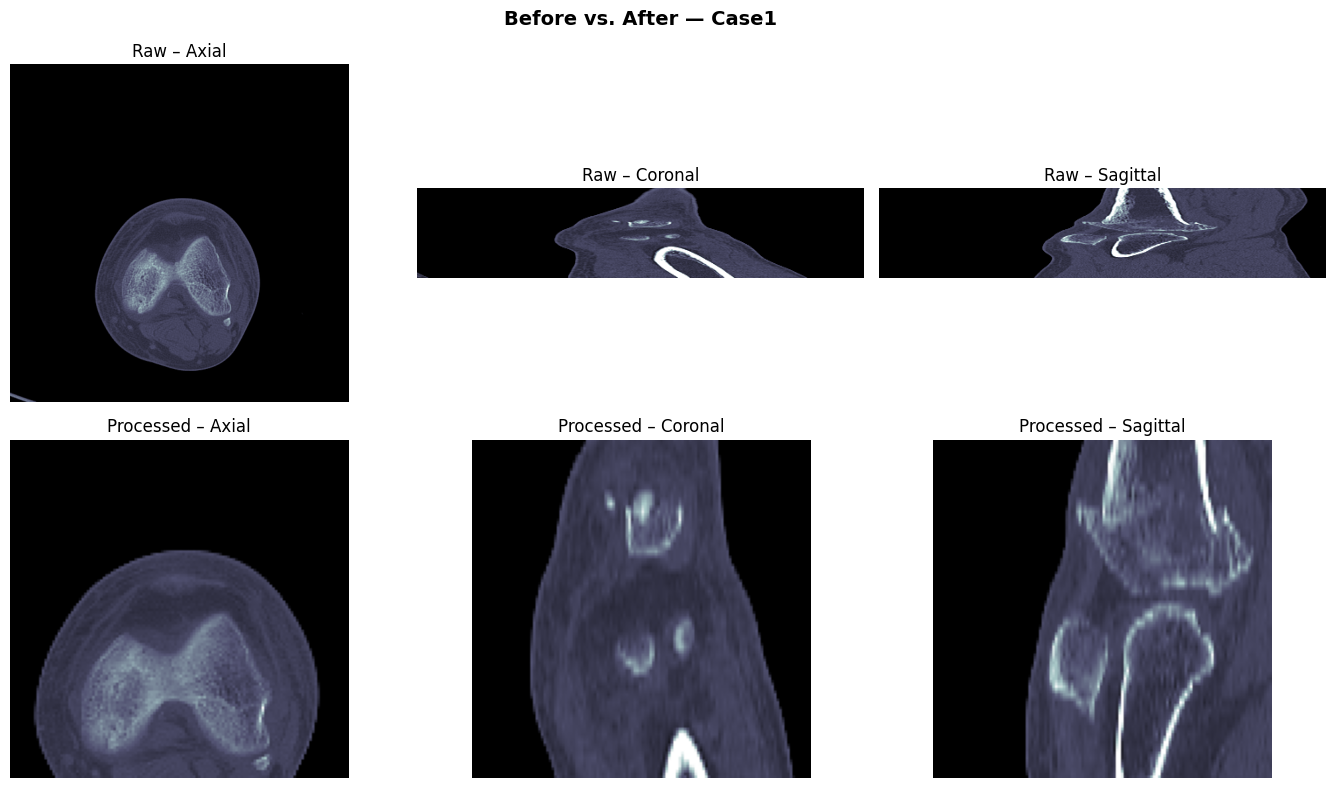

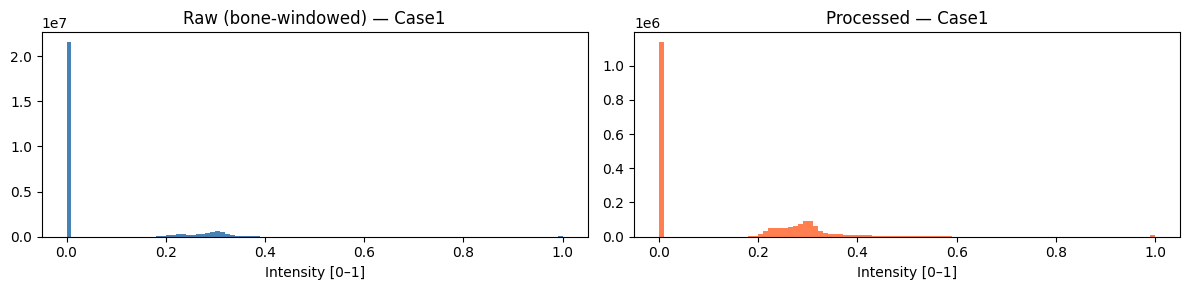

In [9]:
def show_comparison(raw_path: str, proc_path: str, case_id: str):
    """Show axial / coronal / sagittal mid-slices before and after processing."""
    raw_img  = load_dicom_volume(raw_path)
    proc_img = sitk.ReadImage(proc_path)

    raw_arr  = sitk.GetArrayFromImage(raw_img).astype(np.float32)
    proc_arr = sitk.GetArrayFromImage(proc_img)

    # Apply bone window to raw for fair visual comparison
    raw_windowed = apply_bone_window(raw_arr)

    planes = ["Axial", "Coronal", "Sagittal"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"Before vs. After — {case_id}", fontsize=14, fontweight="bold")

    for col, (plane, axis) in enumerate(zip(planes, [0, 1, 2])):
        mid = raw_windowed.shape[axis] // 2
        raw_slice  = np.take(raw_windowed, mid, axis=axis)
        mid_p = proc_arr.shape[axis] // 2
        proc_slice = np.take(proc_arr, mid_p, axis=axis)

        axes[0, col].imshow(raw_slice, cmap="bone", vmin=0, vmax=1)
        axes[0, col].set_title(f"Raw – {plane}")
        axes[0, col].axis("off")

        axes[1, col].imshow(proc_slice, cmap="bone", vmin=0, vmax=1)
        axes[1, col].set_title(f"Processed – {plane}")
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()

    # Intensity histogram
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].hist(raw_windowed.ravel(), bins=100, color="steelblue", edgecolor="none")
    axes[0].set_title(f"Raw (bone-windowed) — {case_id}")
    axes[0].set_xlabel("Intensity [0–1]")
    axes[1].hist(proc_arr.ravel(), bins=100, color="coral", edgecolor="none")
    axes[1].set_title(f"Processed — {case_id}")
    axes[1].set_xlabel("Intensity [0–1]")
    plt.tight_layout()
    plt.show()


# Visualize the first processed case
sample_row = df_results.iloc[0]
show_comparison(
    raw_path=df_valid.iloc[0]["case_path"],
    proc_path=sample_row["output_path"],
    case_id=sample_row["case_id"],
)